# ADEF v3

**Adaptive Evidential Fusion with Learned Soft Conflict Gating & Deep Gated Co-Attention**

v2 → v3 improvements:
1. **Soft-learnable conflict gate** — differentiable σ((K−τ)/s), replaces hard τ-mask
2. **Deep gated co-attention** — 2 stacked layers with tanh-gated residual updates
3. **Vacuous-opinion dropout** — train-time modality dropout via DST vacuous beliefs (b=0,u=1)
4. **Jøsang uncertainty discounting** — learned per-branch reliability scalars
5. **Digamma evidential loss** — expected cross-entropy (less overconfidence than SoS)
6. **Label smoothing 0.05 + sqrt-class-weights + GAMMA=0.1**
7. **Early stopping** (patience 6) + **3-seed** evaluation (mean±std)


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms
import torchvision.models as models
from transformers import RobertaTokenizer, RobertaModel

from PIL import Image
import pandas as pd
import numpy as np
import os
import warnings
import random
import copy
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ============================================================
# REPRODUCIBILITY
# ============================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("✅ Imports loaded & seed set.")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


C:\Users\Residensi ADW\AppData\Roaming\Python\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports loaded & seed set.
PyTorch version: 2.5.1
CUDA available: True
GPU: NVIDIA GeForce RTX 3060


In [2]:
# ============================================================
# CONFIGURATION v3 (single source of truth for ALL hyperparameters)
# ============================================================

class CFG:
    # =========================
    # PATH
    # =========================
    ROOT_DIR = r"D:/MVSA_SINGLE"
    DATA_DIR = r"D:/MVSA_SINGLE/data"
    LABEL_PATH = r"D:/MVSA_SINGLE/labelResultAllFinal.txt"

    # =========================
    # DEVICE
    # =========================
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # =========================
    # DATA
    # =========================
    FILTER_CONFLICT_PAIRS = True     # True = baseline-compatible; False = ablation (real conflict)

    # =========================
    # OPTIMIZATION HYPERPARAMETERS
    # =========================
    BATCH_SIZE = 16
    EPOCHS = 30
    LR = 1e-4
    WEIGHT_DECAY = 1e-3              # v3: stronger regularization (was 1e-4)
    GRAD_CLIP = 1.0
    SCHED_TMAX = 30
    DROPOUT = 0.45                   # v3: higher dropout (was 0.3; 3 heads + co-attn >> baseline params)
    SEED = 42
    SEEDS = [42, 1337, 2024]         # v3: 3-seed evaluation

    # =========================
    # EARLY STOPPING (v3)
    # =========================
    EARLY_STOP_PATIENCE = 6

    # =========================
    # ARCHITECTURE HYPERPARAMETERS
    # =========================
    MAX_LEN = 150
    D_BERT = 768
    D_CNN = 1024
    D_PROJ = 512
    NUM_CLASSES = 3
    COATTN_LAYERS = 2                # v3: stacked gated co-attention

    # =========================
    # EDL / ADEF v3 HYPERPARAMETERS
    # =========================
    ANNEALING_EPOCHS = 10
    EDL_LOSS_TYPE = "digamma"        # v3: "digamma" (expected-CE) | "sos" (Bayes risk) | "both"
    LABEL_SMOOTHING = 0.05           # v3: smooth one-hot labels in loss
    TAU = 0.036                      # init from v2 val p80; learnable gate uses this as center
    GATE_TYPE = "parametric"         # v3: "parametric" (sigma((K-tau)/s)) | "mlp"
    GATE_LEARNABLE = True            # v3: tau & s learnable
    GATE_TEMP_INIT = 0.02            # v3: initial temperature for sigmoid gate
    OPINION_DROP_PROB = 0.15         # v3: vacuous-opinion dropout prob (train only)
    USE_DISCOUNTING = True           # v3: Josang pre-fusion discounting
    GAMMA = 0.1                      # v3: L_con weight (was 1.0 -- suppressed conflict!)
    LAMBDA_FUSED = 1.0
    USE_CLASS_WEIGHTS = True
    CLASS_WEIGHT_MODE = "sqrt_inv"   # v3: "sqrt_inv" (sqrt inverse freq) | "inv"
    U_MIN = 0.05

    # =========================
    # MODEL SELECTION / EVALUATION
    # =========================
    SELECT_METRIC = "macro_f1"
    UCE_BINS = 10

    # =========================
    # PRETRAINED MODELS
    # =========================
    TEXT_MODEL = "roberta-base"
    IMAGE_MODEL = "densenet121"

print(f"\u2705 CFG v3 loaded. Device: {CFG.DEVICE}  |  Gate: {CFG.GATE_TYPE}  |  Loss: {CFG.EDL_LOSS_TYPE}")
print(f"   CoAttn layers={CFG.COATTN_LAYERS}  Drop={CFG.OPINION_DROP_PROB}  Discount={CFG.USE_DISCOUNTING}  Gamma={CFG.GAMMA}")


✅ CFG v3 loaded. Device: cuda  |  Gate: parametric  |  Loss: digamma
   CoAttn layers=2  Drop=0.15  Discount=True  Gamma=0.1


In [3]:
import pandas as pd
import os
# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(CFG.LABEL_PATH, header=0, sep=",")
df.columns = ["id", "text_label", "image_label", "final_label"]

# Filter contradictory text-image pairs (text+ / image- and vice versa).
# NOTE: these ARE the cross-modal conflict cases ADEF Route B was designed for.
# Default True keeps the dataset identical to the 4 baseline notebooks
# (fair comparison). Set CFG.FILTER_CONFLICT_PAIRS = False for ablation.
def is_valid(row):

    if row["text_label"] == "positive" and row["image_label"] == "negative":
        return False

    if row["text_label"] == "negative" and row["image_label"] == "positive":
        return False

    return True

if CFG.FILTER_CONFLICT_PAIRS:
    df = df[df.apply(is_valid, axis=1)]
    df = df.reset_index(drop=True)

print(f"Dataset size after filtering: {len(df)}  (FILTER_CONFLICT_PAIRS={CFG.FILTER_CONFLICT_PAIRS})")

label_map = {
    "negative": 0,
    "neutral": 1,
    "positive": 2
}

id2label = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

df["label"] = df["final_label"].map(label_map)

# Load text file dengan better error handling
def load_text(sample_id):
    path = os.path.join(CFG.DATA_DIR, f"{sample_id}.txt")

    encodings = ["utf-8", "latin-1", "cp1252", "iso-8859-1"]

    for encoding in encodings:
        try:
            with open(path, "r", encoding=encoding) as f:
                text = f.read().strip()
                if text:  # Jika text berhasil dibaca dan tidak kosong
                    return text
        except FileNotFoundError:
            continue
        except Exception as e:
            continue

    # Jika semua encoding gagal atau file tidak ada
    return ""

df["text"] = df["id"].apply(load_text)

# Hitung empty text
empty_text_count = (df["text"] == "").sum()
print(f"\n{'='*60}")
print(f"PREPROCESSING STATISTICS:")
print(f"{'='*60}")
print(f"Total samples: {len(df)}")
print(f"Samples with EMPTY text: {empty_text_count}")
print(f"Samples with VALID text: {len(df) - empty_text_count}")
print(f"Percentage of empty text: {(empty_text_count/len(df)*100):.2f}%")
print(f"{'='*60}\n")

# image path
df["image_path"] = df["id"].apply(
    lambda x: os.path.join(CFG.DATA_DIR, f"{x}.jpg")
)

df.head()

Dataset size after filtering: 4511  (FILTER_CONFLICT_PAIRS=True)

PREPROCESSING STATISTICS:
Total samples: 4511
Samples with EMPTY text: 0
Samples with VALID text: 4511
Percentage of empty text: 0.00%



,id,text_label,image_label,final_label,label,text,image_path
0,1,neutral,positive,positive,2,How I feel today #legday #jelly #aching #gym,D:/MVSA_SINGLE/data\1.jpg
1,2,neutral,positive,positive,2,grattis min griskulting!!!???? va bara tvungen...,D:/MVSA_SINGLE/data\2.jpg
2,3,neutral,positive,positive,2,RT @polynminion: The moment I found my favouri...,D:/MVSA_SINGLE/data\3.jpg
3,4,positive,positive,positive,2,#escort We have a young and energetic team and...,D:/MVSA_SINGLE/data\4.jpg
4,5,positive,positive,positive,2,"RT @chrisashaffer: Went to SSC today to be a ""...",D:/MVSA_SINGLE/data\5.jpg


In [4]:
# ============================================================
# PYTORCH DATASET & DATALOADERS
# ============================================================

# MVSADataset: PyTorch Dataset for MVSA multimodal sentiment analysis.
class MVSADataset(Dataset):

    def __init__(self, dataframe, tokenizer, transform, max_len=150):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.transform = transform
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        text = str(row["text"]) if pd.notna(row["text"]) else ""
        image_path = row["image_path"]
        label = int(row["label"])

        # Tokenize text
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # Load and transform image
        try:
            image = Image.open(image_path).convert("RGB")
            image = self.transform(image)
        except Exception:
            image = torch.zeros(3, 224, 224)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": image,
            "label": torch.tensor(label, dtype=torch.long)
        }


# ============================================================
# INITIALIZE TOKENIZER & TRANSFORMS
# ============================================================
tokenizer = RobertaTokenizer.from_pretrained(CFG.TEXT_MODEL)

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================================================
# STRATIFIED SPLIT: 70% train, 15% val, 15% test
# ============================================================
train_df, temp_df = train_test_split(
    df, test_size=0.3, stratify=df["label"], random_state=CFG.SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["label"], random_state=CFG.SEED
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(f"\nTrain label distribution:")
print(train_df['label'].value_counts().sort_index())
print(f"\nVal label distribution:")
print(val_df['label'].value_counts().sort_index())
print(f"\nTest label distribution:")
print(test_df['label'].value_counts().sort_index())

# Create datasets
train_dataset = MVSADataset(train_df, tokenizer, image_transform, CFG.MAX_LEN)
val_dataset = MVSADataset(val_df, tokenizer, image_transform, CFG.MAX_LEN)
test_dataset = MVSADataset(test_df, tokenizer, image_transform, CFG.MAX_LEN)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=CFG.BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=CFG.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"\n\u2705 DataLoaders created.")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")


Train: 3157 | Val: 677 | Test: 677

Train label distribution:
label
0     950
1     329
2    1878
Name: count, dtype: int64

Val label distribution:
label
0    204
1     71
2    402
Name: count, dtype: int64

Test label distribution:
label
0    204
1     70
2    403
Name: count, dtype: int64

✅ DataLoaders created.
Train batches: 198 | Val batches: 43 | Test batches: 43


In [5]:
# ============================================================
# FEATURE EXTRACTORS (Sequence-Level for Co-Attention)
# ============================================================

# RoBERTa text encoder -> token-level features + masked mean-pooled vector.
# v1 pooled to a single vector BEFORE attention, degenerating the attention
# matrix to a scalar. v2 keeps token-level features for fine-grained alignment.
# Input:  input_ids [B, L_t], attention_mask [B, L_t]
# Output: H_t  [B, L_t, d_proj] (token features for co-attention)
#         h_t  [B, d_proj]      (pooled vector for unimodal ENN head)
#         attention_mask [B, L_t]
class TextEncoder(nn.Module):

    def __init__(self, d_bert=768, d_proj=512):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(CFG.TEXT_MODEL)
        # Freeze RoBERTa parameters (fair comparison with baseline notebooks)
        for param in self.roberta.parameters():
            param.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(d_bert, d_proj),
            nn.ReLU(),
            nn.LayerNorm(d_proj)
        )

    def forward(self, input_ids, attention_mask):
        with torch.no_grad():
            outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        H_t = self.projection(outputs.last_hidden_state)  # [B, L_t, d_proj]

        # Masked mean-pooling -> pooled text vector
        mask = attention_mask.unsqueeze(-1).float()       # [B, L_t, 1]
        h_t = (H_t * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-10)  # [B, d_proj]
        return H_t, h_t, attention_mask


# DenseNet-121 image encoder -> spatial (patch) features + pooled vector.
# Input:  image [B, 3, 224, 224]
# Output: H_v [B, N_v, d_proj] (N_v = 49 patch features for co-attention)
#         h_v [B, d_proj]      (pooled vector for unimodal ENN head)
class ImageEncoder(nn.Module):

    def __init__(self, d_cnn=1024, d_proj=512):
        super().__init__()
        densenet = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)
        self.features = densenet.features
        # Freeze DenseNet parameters
        for param in self.features.parameters():
            param.requires_grad = False

        self.projection = nn.Sequential(
            nn.Linear(d_cnn, d_proj),
            nn.ReLU(),
            nn.LayerNorm(d_proj)
        )

    def forward(self, x):
        with torch.no_grad():
            features = self.features(x)  # [B, 1024, 7, 7]
        B, C, H, W = features.shape

        # Spatial features: [B, N_v, 1024] -> project
        H_v = features.view(B, C, H * W).permute(0, 2, 1)  # [B, N_v, 1024]
        H_v = self.projection(H_v)                          # [B, N_v, d_proj]
        h_v = H_v.mean(dim=1)                               # [B, d_proj]
        return H_v, h_v


print("\u2705 TextEncoder (sequence) & ImageEncoder (spatial) defined.")

✅ TextEncoder (sequence) & ImageEncoder (spatial) defined.


In [6]:
# ============================================================
# DEEP GATED BI-COATTENTION (v3)
# ============================================================
# Stacks N layers of simultaneous gated bidirectional co-attention.
# Each layer applies text->visual AND visual->text attention in parallel
# using the SAME input features, then updates both modalities via
# tanh-gated residual connections.
#
# Layer l:
#   S   = H_t @ W_l @ H_v^T / sqrt(d)           -- affinity [B, L_t, N_v]
#   v2t = softmax(S, dim=patches) @ H_v          -- text-attended visual features
#   t2v = softmax(S^T, dim=tokens, masked) @ H_t -- visual-attended text features
#   H_t <- H_t + tanh(Linear_t(H_t)) * v2t       -- gated residual (text)
#   H_v <- H_v + tanh(Linear_v(H_v)) * t2v       -- gated residual (visual)
#
# Final h_c: concat(masked-mean(H_t_final), mean(H_v_final)) -> MLP -> [d]
# The gating allows the model to learn HOW MUCH cross-modal information
# to absorb at each layer, preventing co-adaptation overfitting.


class GatedBiCoAttention(nn.Module):
    def __init__(self, d_proj=512, dropout=0.45, num_layers=2):
        super().__init__()
        self.d_proj = d_proj
        self.num_layers = num_layers

        for layer_idx in range(num_layers):
            setattr(self, f"W_attn_{layer_idx}", nn.Linear(d_proj, d_proj, bias=False))
            setattr(self, f"gate_t_{layer_idx}", nn.Linear(d_proj, d_proj))
            setattr(self, f"gate_v_{layer_idx}", nn.Linear(d_proj, d_proj))

        self.fusion_proj = nn.Sequential(
            nn.Linear(2 * d_proj, d_proj),
            nn.ReLU(),
            nn.LayerNorm(d_proj),
            nn.Dropout(dropout)
        )

    def forward(self, H_t, H_v, text_mask):
        # H_t: [B, L_t, d_proj]   H_v: [B, N_v, d_proj]   text_mask: [B, L_t]
        pad_mask = (text_mask == 0).unsqueeze(1)  # [B, 1, L_t]

        for layer_idx in range(self.num_layers):
            W = getattr(self, f"W_attn_{layer_idx}")
            gate_t = getattr(self, f"gate_t_{layer_idx}")
            gate_v = getattr(self, f"gate_v_{layer_idx}")

            # Affinity matrix
            S = torch.bmm(W(H_t), H_v.transpose(1, 2)) / (self.d_proj ** 0.5)  # [B, L_t, N_v]

            # Text -> Visual (each token attends over all patches)
            A_tv = F.softmax(S, dim=-1)                # [B, L_t, N_v]
            v2t = torch.bmm(A_tv, H_v)                  # [B, L_t, d]

            # Visual -> Text (each patch attends over non-pad tokens)
            S_T = S.transpose(1, 2).masked_fill(pad_mask, -1e9)  # [B, N_v, L_t]
            A_vt = F.softmax(S_T, dim=-1)              # [B, N_v, L_t]
            t2v = torch.bmm(A_vt, H_t)                  # [B, N_v, d]

            # Gated residual (SIMULTANEOUS: both use input H_t, H_v, not updated mid-layer)
            H_t = H_t + torch.tanh(gate_t(H_t)) * v2t
            H_v = H_v + torch.tanh(gate_v(H_v)) * t2v

        # Pooling: masked-mean for text, mean for visual
        mask = text_mask.unsqueeze(-1).float()
        t_summary = (H_t * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-10)
        v_summary = H_v.mean(dim=1)
        h_c = self.fusion_proj(torch.cat([t_summary, v_summary], dim=1))
        return h_c


print("\u2705 GatedBiCoAttention (v3, {CFG.COATTN_LAYERS}-layer) defined.".format(CFG=CFG))


✅ GatedBiCoAttention (v3, 2-layer) defined.


In [7]:
# ============================================================
# ENN HEAD & SUBJECTIVE LOGIC UTILITIES
# ============================================================

class ENNHead(nn.Module):
    def __init__(self, d_proj=512, num_classes=3, dropout=0.45):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(d_proj, d_proj // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_proj // 2, num_classes),
            nn.Softplus()
        )

    def forward(self, h):
        evidence = self.fc(h)
        alpha = evidence + 1
        return alpha


def compute_belief_uncertainty(alpha, num_classes=3, eps=1e-8):
    S = torch.sum(alpha, dim=1, keepdim=True)
    e = alpha - 1
    b = e / (S + eps)
    u = num_classes / (S + eps)
    return b, u, S


# ============================================================
# JOSANG'S DISCOUNTING OPERATOR (v3)
# ============================================================
# Applies pre-fusion reliability discounting per branch.
#   b' = r * b
#   u' = 1 - r * (1 - u)  =  r*u + (1-r)
# r = 1: identity (fully trust the branch)
# r -> 0: vacuous opinion (b=0, u=1) -- "I don't know"
# Learned scalar r = sigmoid(raw_r), initialized to ~0.9


class ReliabilityDiscounter(nn.Module):
    def __init__(self, name="t"):
        super().__init__()
        self.name = name
        self.raw_r = nn.Parameter(torch.tensor(2.197, dtype=torch.float32))  # sigmoid(2.197) ~ 0.9

    def forward(self, b, u):
        r = torch.sigmoid(self.raw_r)
        b_discounted = r * b
        u_discounted = r * u + (1.0 - r)
        return b_discounted, u_discounted


print("\u2705 ENNHead, Subjective Logic utils & ReliabilityDiscounter defined.")


✅ ENNHead, Subjective Logic utils & ReliabilityDiscounter defined.


In [8]:
# ============================================================
# SOFT CONFLICT GATE (v3 -- differentiable, learnable)
# ============================================================
# Replaces the hard route_a_mask with a smooth sigmoid gate:
#   parametric:  g = sigma((K_tv - tau) / s),  tau in [0.01, 0.5], s > 0
#   mlp:         g = MLP([K_tv, u_t, u_v, u_c, L1(p_t, p_v)]) -> [0,1]
#
# Final fusion = (1 - g) * DS_fused  +  g * conflict_resolved
# Both routes ALWAYS contribute via soft blending; gradients flow through g
# back into the ENN heads via K_tv. This makes "Adaptive" truly LEARNED.


class SoftConflictGate(nn.Module):
    def __init__(self, gate_type="parametric", init_tau=0.036, init_temp=0.02):
        super().__init__()
        self.gate_type = gate_type

        if gate_type == "parametric":
            # tau = 0.01 + 0.49 * sigmoid(theta_tau)  ->  tau in [0.01, 0.5]
            tau_raw_val = np.log(init_tau / (0.5 - init_tau)) if init_tau < 0.5 else 5.0
            self.theta_tau = nn.Parameter(torch.tensor(tau_raw_val, dtype=torch.float32))
            # s = softplus(theta_temp) + 1e-4  ->  s > 0
            temp_raw_val = np.log(init_temp)
            self.theta_temp = nn.Parameter(torch.tensor(temp_raw_val, dtype=torch.float32))

        elif gate_type == "mlp":
            self.gate_net = nn.Sequential(
                nn.Linear(5, 16),
                nn.ReLU(),
                nn.Linear(16, 1),
                nn.Sigmoid()
            )
        else:
            raise ValueError(f"Unknown gate_type: {gate_type}")

    def forward(self, K_tv, u_t, u_v, u_c, p_t, p_v):
        if self.gate_type == "parametric":
            tau = 0.01 + 0.49 * torch.sigmoid(self.theta_tau)
            s = F.softplus(self.theta_temp) + 1e-4
            g = torch.sigmoid((K_tv - tau) / s)
        else:  # mlp
            features = torch.cat([
                K_tv,
                u_t, u_v, u_c,
                torch.abs(p_t - p_v).mean(dim=1, keepdim=True)
            ], dim=1)
            g = self.gate_net(features)
        return g   # [B, 1], g ~ 1 = conflict, g ~ 0 = agree


# ============================================================
# ADEF v3 MODULE (soft routing + discounting + Dempster)
# ============================================================

class ADEFModuleV3(nn.Module):
    def __init__(self, num_classes=3, gate_type="parametric", init_tau=0.036,
                 init_temp=0.02, use_discounting=True):
        super().__init__()
        self.num_classes = num_classes
        self.use_discounting = use_discounting

        self.gate = SoftConflictGate(gate_type=gate_type, init_tau=init_tau,
                                     init_temp=init_temp)

        if use_discounting:
            self.discounter_t = ReliabilityDiscounter(name="t")
            self.discounter_v = ReliabilityDiscounter(name="v")
            self.discounter_c = ReliabilityDiscounter(name="c")

    def dempster_combine(self, b1, u1, b2, u2):
        eps = 1e-8
        b1_sum = torch.sum(b1, dim=1, keepdim=True)
        b2_sum = torch.sum(b2, dim=1, keepdim=True)
        C = b1_sum * b2_sum - torch.sum(b1 * b2, dim=1, keepdim=True)
        norm = 1.0 / torch.clamp(1.0 - C, min=eps)
        b_fused = norm * (b1 * b2 + b1 * u2 + b2 * u1)
        u_fused = norm * (u1 * u2)
        return b_fused, u_fused, C

    def forward(self, b_t, u_t, b_v, u_v, b_c, u_c):
        eps = 1e-8
        K = self.num_classes

        # --- 1. Discount opinions before fusion ---
        if self.use_discounting:
            b_t_d, u_t_d = self.discounter_t(b_t, u_t)
            b_v_d, u_v_d = self.discounter_v(b_v, u_v)
            b_c_d, u_c_d = self.discounter_c(b_c, u_c)
        else:
            b_t_d, u_t_d = b_t, u_t
            b_v_d, u_v_d = b_v, u_v
            b_c_d, u_c_d = b_c, u_c

        # --- 2. Class probabilities & conflict K_tv for gate ---
        p_t = b_t_d + u_t_d / K
        p_v = b_v_d + u_v_d / K

        b_t_sum_d = torch.sum(b_t_d, dim=1, keepdim=True)
        b_v_sum_d = torch.sum(b_v_d, dim=1, keepdim=True)
        K_tv = b_t_sum_d * b_v_sum_d - torch.sum(b_t_d * b_v_d, dim=1, keepdim=True)

        # --- 3. Soft conflict gate ---
        g = self.gate(K_tv, u_t_d, u_v_d, u_c_d, p_t, p_v)  # [B, 1]

        # --- 4. Route A: standard 2-stage Dempster fusion ---
        b_tv_a, u_tv_a, _ = self.dempster_combine(b_t_d, u_t_d, b_v_d, u_v_d)
        b_final_a, u_final_a, _ = self.dempster_combine(b_tv_a, u_tv_a, b_c_d, u_c_d)

        # --- 5. Route B: conflict-aware blending ---
        b_avg = (b_t_d + b_v_d) / 2.0
        b_final_b = (1.0 - K_tv) * b_avg + K_tv * b_c_d
        u_final_b = torch.clamp(1.0 - torch.sum(b_final_b, dim=1, keepdim=True), min=eps)

        # --- 6. Soft blend: final = (1-g) * RouteA + g * RouteB ---
        b_fusion = (1.0 - g) * b_final_a + g * b_final_b
        u_fusion = torch.clamp((1.0 - g) * u_final_a + g * u_final_b, min=eps, max=1.0)

        # --- 7. Final decision ---
        p_final = b_fusion + u_fusion / K

        return p_final, b_fusion, u_fusion, K_tv, g


print("\u2705 ADEFModuleV3 with soft conflict gate defined.")


✅ ADEFModuleV3 with soft conflict gate defined.


In [9]:
# ============================================================
# ADEFCoAttnNet v3
# ============================================================
# Changes from v2:
#   - GatedBiCoAttention (deep gated co-attention instead of 1-layer)
#   - Soft-learned conflict gate (differentiable routing)
#   - Vacuous-opinion dropout at train time (modality dropout via DST)
#   - Josang reliability discounting before fusion


class ADEFCoAttnNetV3(nn.Module):
    def __init__(self, d_proj=512, num_classes=3, dropout=0.45,
                 coattn_layers=2, gate_type="parametric", init_tau=0.036,
                 init_temp=0.02, use_discounting=True, opinion_drop_prob=0.0):
        super().__init__()
        # Feature extractors (sequence-level)
        self.text_encoder = TextEncoder(d_bert=CFG.D_BERT, d_proj=d_proj)
        self.image_encoder = ImageEncoder(d_cnn=CFG.D_CNN, d_proj=d_proj)

        # Deep gated co-attention
        self.co_attention = GatedBiCoAttention(
            d_proj=d_proj, dropout=dropout, num_layers=coattn_layers
        )

        # 3 independent ENN heads
        self.enn_text = ENNHead(d_proj=d_proj, num_classes=num_classes, dropout=dropout)
        self.enn_image = ENNHead(d_proj=d_proj, num_classes=num_classes, dropout=dropout)
        self.enn_coattn = ENNHead(d_proj=d_proj, num_classes=num_classes, dropout=dropout)

        # ADEF v3 fusion module (soft gate + discounting)
        self.adef = ADEFModuleV3(
            num_classes=num_classes, gate_type=gate_type, init_tau=init_tau,
            init_temp=init_temp, use_discounting=use_discounting
        )

        self.num_classes = num_classes
        self.opinion_drop_prob = opinion_drop_prob

    def forward(self, input_ids, attention_mask, image):
        # 1. Feature extraction (sequence-level + pooled)
        H_t, h_t, text_mask = self.text_encoder(input_ids, attention_mask)
        H_v, h_v = self.image_encoder(image)

        # 2. Deep gated co-attention
        h_c = self.co_attention(H_t, H_v, text_mask)

        # 3. ENN Heads -> Dirichlet parameters
        alpha_t = self.enn_text(h_t)
        alpha_v = self.enn_image(h_v)
        alpha_c = self.enn_coattn(h_c)

        # 4. Subjective Logic: belief & uncertainty
        b_t, u_t, _ = compute_belief_uncertainty(alpha_t, self.num_classes)
        b_v, u_v, _ = compute_belief_uncertainty(alpha_v, self.num_classes)
        b_c, u_c, _ = compute_belief_uncertainty(alpha_c, self.num_classes)

        # 5. Vacuous-opinion dropout (train only)
        #    Replace each unimodal opinion with vacuous (b=0, u=1) with prob p.
        #    DST identity: Dempster(vacuous, omega) = omega.
        #    This trains the fusion to handle missing/unreliable modalities
        #    and directly regularizes co-adaptation overfitting.
        if self.training and self.opinion_drop_prob > 0.0:
            B = b_t.shape[0]
            dev = b_t.device
            keep_t = (torch.rand(B, 1, device=dev) > self.opinion_drop_prob).float()
            keep_v = (torch.rand(B, 1, device=dev) > self.opinion_drop_prob).float()
            b_t = b_t * keep_t
            u_t = u_t * keep_t + (1.0 - keep_t)
            b_v = b_v * keep_v
            u_v = u_v * keep_v + (1.0 - keep_v)

        # 6. ADEF fusion (soft gate + discounting)
        p_final, b_fusion, u_fusion, K_tv, gate = self.adef(
            b_t, u_t, b_v, u_v, b_c, u_c
        )

        return {
            "alpha_t": alpha_t, "alpha_v": alpha_v, "alpha_c": alpha_c,
            "b_t": b_t, "u_t": u_t,
            "b_v": b_v, "u_v": u_v,
            "b_c": b_c, "u_c": u_c,
            "p_final": p_final,
            "b_fusion": b_fusion, "u_fusion": u_fusion,
            "K_tv": K_tv,
            "gate": gate   # v3: soft gate value [B, 1]
        }


def create_model_v3(overrides=None):
    """Create v3 model with optional override kwargs (for ablation tests)."""
    kwargs = dict(
        d_proj=CFG.D_PROJ, num_classes=CFG.NUM_CLASSES, dropout=CFG.DROPOUT,
        coattn_layers=CFG.COATTN_LAYERS, gate_type=CFG.GATE_TYPE,
        init_tau=CFG.TAU, init_temp=CFG.GATE_TEMP_INIT,
        use_discounting=CFG.USE_DISCOUNTING,
        opinion_drop_prob=CFG.OPINION_DROP_PROB
    )
    if overrides:
        kwargs.update(overrides)
    return ADEFCoAttnNetV3(**kwargs).to(CFG.DEVICE)


model = create_model_v3()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\u2705 ADEFCoAttnNetV3 created.")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Frozen parameters: {total_params - trainable_params:,}")


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6428.03it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ ADEFCoAttnNetV3 created.
Total parameters: 135,017,102
Trainable parameters: 3,417,614
Frozen parameters: 131,599,488


In [10]:
# ============================================================
# BLENDED LOSS FUNCTION v3
# L_overall = L_sup + lambda_f * L_fused + gamma * L_con
# ============================================================
# Changes from v2:
#   1. Digamma (expected-CE) loss -- less overconfidence-prone than Sum-of-Squares
#   2. Label smoothing (0.05) in loss targets
#   3. Sqrt-inverse-freq class weights (gentler than full inverse; recovers Neutral precision)
#   4. GAMMA = 0.1 (L_con no longer suppresses cross-modal conflict signal)


class EvidentialLossV3(nn.Module):
    def __init__(self, num_classes=3, annealing_epochs=10, class_weights=None,
                 loss_type="digamma", label_smoothing=0.05):
        super().__init__()
        self.num_classes = num_classes
        self.annealing_epochs = annealing_epochs
        self.class_weights = class_weights
        self.loss_type = loss_type
        self.label_smoothing = label_smoothing

    def _smooth_labels(self, y_onehot):
        if self.label_smoothing > 0:
            return (1.0 - self.label_smoothing) * y_onehot + \
                   self.label_smoothing / self.num_classes
        return y_onehot

    # ---- Expected Cross-Entropy (Digamma) Loss ----
    # L_ce = sum_j y_j * (psi(S) - psi(alpha_j))
    def digamma_loss(self, alpha, y_onehot, sample_weight=None):
        alpha = torch.clamp(alpha, min=1e-10)
        S = torch.sum(alpha, dim=1, keepdim=True)
        loss = torch.sum(y_onehot * (torch.digamma(S) - torch.digamma(alpha)), dim=1)
        if sample_weight is not None:
            loss = loss * sample_weight
        return loss.mean()

    # ---- Bayes Risk (Sum-of-Squares) Loss (v2 default) ----
    def bayes_risk_loss(self, alpha, y_onehot, sample_weight=None):
        alpha = torch.clamp(alpha, min=1e-10)
        S = torch.sum(alpha, dim=1, keepdim=True)
        p_hat = alpha / S
        err = torch.sum((y_onehot - p_hat) ** 2, dim=1)
        var = torch.sum(p_hat * (1.0 - p_hat) / (S + 1.0), dim=1)
        loss = err + var
        if sample_weight is not None:
            loss = loss * sample_weight
        return loss.mean()

    # ---- KL Divergence to uniform Dirichlet ----
    def kl_divergence_reg(self, alpha, y_onehot):
        alpha = torch.clamp(alpha, min=1e-10)
        K = self.num_classes
        alpha_tilde = y_onehot + (1.0 - y_onehot) * alpha
        alpha_tilde = torch.clamp(alpha_tilde, min=1e-10)
        S_tilde = torch.sum(alpha_tilde, dim=1, keepdim=True)

        kl = (
            torch.lgamma(S_tilde)
            - torch.lgamma(torch.tensor(float(K), device=alpha.device))
            - torch.sum(torch.lgamma(alpha_tilde), dim=1, keepdim=True)
            + torch.sum(
                (alpha_tilde - 1.0) * (torch.digamma(alpha_tilde) - torch.digamma(S_tilde)),
                dim=1, keepdim=True
            )
        )
        return kl.mean()

    def forward(self, alpha, labels, epoch):
        y_onehot = self._smooth_labels(
            F.one_hot(labels, num_classes=self.num_classes).float()
        )
        lambda_t = min(1.0, epoch / max(self.annealing_epochs, 1))
        sw = self.class_weights[labels] if self.class_weights is not None else None

        if self.loss_type == "digamma":
            loss_err = self.digamma_loss(alpha, y_onehot, sw)
        elif self.loss_type == "sos":
            loss_err = self.bayes_risk_loss(alpha, y_onehot, sw)
        else:  # "both"
            loss_err = (self.digamma_loss(alpha, y_onehot, sw)
                        + self.bayes_risk_loss(alpha, y_onehot, sw)) / 2.0

        loss_kl = self.kl_divergence_reg(alpha, y_onehot)
        return loss_err + lambda_t * loss_kl


# Reconstruct Dirichlet alpha from fused Subjective-Logic opinion
def opinion_to_dirichlet(b, u, num_classes=3, u_min=0.05):
    u_c = torch.clamp(u, min=u_min, max=1.0)
    S = num_classes / u_c
    return b * S + 1.0


# Semantic Conflict Loss
# L_con = d_PD * d_CC = 0.5*(1-u_t)*(1-u_v) * sum|p_t - p_v|
# GAMMA = 0.1 stops this from suppressing cross-modal disagreement
def semantic_conflict_loss(alpha_t, alpha_v, num_classes=3, eps=1e-8):
    S_t = torch.sum(alpha_t, dim=1, keepdim=True)
    S_v = torch.sum(alpha_v, dim=1, keepdim=True)
    p_t = alpha_t / (S_t + eps)
    p_v = alpha_v / (S_v + eps)
    u_t = num_classes / (S_t + eps)
    u_v = num_classes / (S_v + eps)
    d_PD = 0.5 * (1.0 - u_t) * (1.0 - u_v)
    d_CC = torch.sum(torch.abs(p_t - p_v), dim=1, keepdim=True)
    return (d_PD * d_CC).mean()


# Sqrt-inverse class weights (gentler than full inverse-frequency)
def get_class_weights_tensor(train_df):
    counts = train_df["label"].value_counts().sort_index().values.astype(np.float32)
    if CFG.CLASS_WEIGHT_MODE == "sqrt_inv":
        weights = np.sqrt(counts.sum() / (CFG.NUM_CLASSES * counts))
    elif CFG.CLASS_WEIGHT_MODE == "inv":
        weights = counts.sum() / (CFG.NUM_CLASSES * counts)
    else:
        return None
    return torch.tensor(weights, dtype=torch.float32, device=CFG.DEVICE)


print("\u2705 EvidentialLossV3 (digamma + label smoothing + sqrt weights) defined.")


✅ EvidentialLossV3 (digamma + label smoothing + sqrt weights) defined.


In [11]:
# ============================================================
# UNCERTAINTY CALIBRATION ERROR (UCE)
# ============================================================

# Compute Expected Uncertainty Calibration Error.
# Bins predictions by uncertainty level, computes weighted
# |error_rate - mean_uncertainty| per bin.
# UCE = sum_j (|B_j|/N) * |err(B_j) - uncert(B_j)|
def compute_uce(predictions, labels, uncertainties, num_bins=10):
    predictions = np.array(predictions)
    labels = np.array(labels)
    uncertainties = np.array(uncertainties)
    uncertainties = np.clip(uncertainties, 0.0, 1.0)

    bin_boundaries = np.linspace(0, 1, num_bins + 1)
    uce = 0.0
    N = len(predictions)

    if N == 0:
        return 0.0

    for i in range(num_bins):
        if i == num_bins - 1:
            mask = (uncertainties >= bin_boundaries[i]) & (uncertainties <= bin_boundaries[i + 1])
        else:
            mask = (uncertainties >= bin_boundaries[i]) & (uncertainties < bin_boundaries[i + 1])

        n_bin = mask.sum()
        if n_bin == 0:
            continue

        bin_errors = (predictions[mask] != labels[mask]).astype(float).mean()
        bin_uncerts = uncertainties[mask].mean()
        uce += (n_bin / N) * np.abs(bin_errors - bin_uncerts)

    return uce


print("\u2705 UCE metric defined.")


✅ UCE metric defined.


In [12]:
# ============================================================
# TRAINING ONE SEED (v3: early stopping, gate statistics, per-seed tracking)
# ============================================================

def train_one_seed(seed, model_kwargs=None):
    """Train the ADEF v3 model for one random seed.
    Returns: (model, best_state_dict, best_val_macro_f1, history_dict)
    """
    set_seed(seed)
    torch.cuda.empty_cache()

    # Build model
    if model_kwargs is None:
        model_kwargs = {}
    model = create_model_v3(model_kwargs)

    # Class weights
    class_weights = None
    if CFG.USE_CLASS_WEIGHTS:
        class_weights = get_class_weights_tensor(train_df)
        print(f"  Class weights (Neg/Neu/Pos): {class_weights.cpu().numpy().round(3).tolist()}")

    criterion = EvidentialLossV3(
        num_classes=CFG.NUM_CLASSES,
        annealing_epochs=CFG.ANNEALING_EPOCHS,
        class_weights=class_weights,
        loss_type=CFG.EDL_LOSS_TYPE,
        label_smoothing=CFG.LABEL_SMOOTHING
    )

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY
    )
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CFG.SCHED_TMAX)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_f1_macro": [], "val_f1_macro": [],
        "train_conflict": [], "val_conflict": [],
        "train_gate": [], "val_gate": []
    }

    best_score = 0.0
    best_state = None
    patience_counter = 0
    best_epoch = 0

    for epoch in range(1, CFG.EPOCHS + 1):
        # ---- TRAIN ----
        model.train()
        train_loss = 0.0
        train_conflict_sum = 0.0
        train_gate_sum = 0.0
        train_preds, train_labels_li = [], []

        pbar = tqdm(train_loader, desc=f"Seed {seed} E{epoch}/{CFG.EPOCHS} [Train]", leave=False)
        for batch in pbar:
            input_ids = batch["input_ids"].to(CFG.DEVICE)
            attention_mask = batch["attention_mask"].to(CFG.DEVICE)
            images = batch["image"].to(CFG.DEVICE)
            labels = batch["label"].to(CFG.DEVICE)

            optimizer.zero_grad()
            out = model(input_ids, attention_mask, images)

            # L_sup = L(alpha_t) + L(alpha_v) + L(alpha_c)
            L_sup = (criterion(out["alpha_t"], labels, epoch)
                     + criterion(out["alpha_v"], labels, epoch)
                     + criterion(out["alpha_c"], labels, epoch))

            # L_fused: directly supervise the fused decision
            alpha_f = opinion_to_dirichlet(out["b_fusion"], out["u_fusion"],
                                           CFG.NUM_CLASSES, CFG.U_MIN)
            L_fused = criterion(alpha_f, labels, epoch)

            # L_con: semantic conflict (gamma = 0.1)
            L_con = semantic_conflict_loss(out["alpha_t"], out["alpha_v"], CFG.NUM_CLASSES)

            loss = L_sup + CFG.LAMBDA_FUSED * L_fused + CFG.GAMMA * L_con

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=CFG.GRAD_CLIP)
            optimizer.step()

            train_loss += loss.item()
            train_conflict_sum += out["K_tv"].mean().item()
            train_gate_sum += out["gate"].mean().item()

            preds = torch.argmax(out["p_final"], dim=1)
            train_preds.extend(preds.cpu().numpy())
            train_labels_li.extend(labels.cpu().numpy())

            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "K_tv": f"{out['K_tv'].mean().item():.3f}",
                "g": f"{out['gate'].mean().item():.3f}"
            })

        scheduler.step()

        # ---- VALIDATE ----
        model.eval()
        val_loss = 0.0
        val_conflict_sum = 0.0
        val_gate_sum = 0.0
        val_preds, val_labels_li = [], []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Seed {seed} E{epoch}/{CFG.EPOCHS} [Val]", leave=False):
                input_ids = batch["input_ids"].to(CFG.DEVICE)
                attention_mask = batch["attention_mask"].to(CFG.DEVICE)
                images = batch["image"].to(CFG.DEVICE)
                labels = batch["label"].to(CFG.DEVICE)

                out = model(input_ids, attention_mask, images)

                L_sup = (criterion(out["alpha_t"], labels, epoch)
                         + criterion(out["alpha_v"], labels, epoch)
                         + criterion(out["alpha_c"], labels, epoch))
                alpha_f = opinion_to_dirichlet(out["b_fusion"], out["u_fusion"],
                                               CFG.NUM_CLASSES, CFG.U_MIN)
                L_fused = criterion(alpha_f, labels, epoch)
                L_con = semantic_conflict_loss(out["alpha_t"], out["alpha_v"], CFG.NUM_CLASSES)
                loss = L_sup + CFG.LAMBDA_FUSED * L_fused + CFG.GAMMA * L_con

                val_loss += loss.item()
                val_conflict_sum += out["K_tv"].mean().item()
                val_gate_sum += out["gate"].mean().item()

                preds = torch.argmax(out["p_final"], dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels_li.extend(labels.cpu().numpy())

        n_train = len(train_loader)
        n_val = len(val_loader)

        # Epoch metrics
        avg_train_loss = train_loss / n_train
        avg_val_loss = val_loss / n_val
        train_acc = accuracy_score(train_labels_li, train_preds)
        val_acc = accuracy_score(val_labels_li, val_preds)
        train_f1m = f1_score(train_labels_li, train_preds, average="macro")
        val_f1m = f1_score(val_labels_li, val_preds, average="macro")
        avg_train_conflict = train_conflict_sum / n_train
        avg_val_conflict = val_conflict_sum / n_val
        avg_train_gate = train_gate_sum / n_train
        avg_val_gate = val_gate_sum / n_val

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1_macro"].append(train_f1m)
        history["val_f1_macro"].append(val_f1m)
        history["train_conflict"].append(avg_train_conflict)
        history["val_conflict"].append(avg_val_conflict)
        history["train_gate"].append(avg_train_gate)
        history["val_gate"].append(avg_val_gate)

        print(f"Seed {seed} E{epoch:2d}/{CFG.EPOCHS} | "
              f"TL: {avg_train_loss:.4f} VL: {avg_val_loss:.4f} | "
              f"TA: {train_acc:.4f} VA: {val_acc:.4f} | "
              f"VF1m: {val_f1m:.4f} | "
              f"K_tv: {avg_val_conflict:.4f} Gate: {avg_val_gate:.3f}")

        # Early stopping based on val Macro-F1
        score = val_f1m
        if score > best_score:
            best_score = score
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
            best_epoch = epoch
            print(f"  * New best! Val F1m: {best_score:.4f}")
        else:
            patience_counter += 1

        if patience_counter >= CFG.EARLY_STOP_PATIENCE:
            print(f"  Early stop at epoch {epoch} (no improvement for {CFG.EARLY_STOP_PATIENCE} epochs)")
            break

    history["best_epoch"] = best_epoch
    history["best_score"] = best_score
    return model, best_state, best_score, history


print("\u2705 train_one_seed() with early stopping defined.")


✅ train_one_seed() with early stopping defined.


In [13]:
# ============================================================
# TEST SET EVALUATION (v3: gate statistics)
# ============================================================

def evaluate_test(model, test_loader):
    """Evaluate on test set. Returns dict of all metrics."""
    model.eval()
    all_preds, all_labels_li = [], []
    all_uncertainties, all_conflicts, all_gates = [], [], []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Test evaluation", leave=False):
            input_ids = batch["input_ids"].to(CFG.DEVICE)
            attention_mask = batch["attention_mask"].to(CFG.DEVICE)
            images = batch["image"].to(CFG.DEVICE)
            labels = batch["label"].to(CFG.DEVICE)

            out = model(input_ids, attention_mask, images)

            preds = torch.argmax(out["p_final"], dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels_li.extend(labels.cpu().numpy())
            all_uncertainties.extend(out["u_fusion"].squeeze(1).cpu().numpy())
            all_conflicts.extend(out["K_tv"].squeeze(1).cpu().numpy())
            all_gates.extend(out["gate"].squeeze(1).cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels_li = np.array(all_labels_li)
    all_uncertainties = np.array(all_uncertainties)
    all_conflicts = np.array(all_conflicts)
    all_gates = np.array(all_gates)

    acc = accuracy_score(all_labels_li, all_preds)
    f1w = f1_score(all_labels_li, all_preds, average="weighted")
    f1m = f1_score(all_labels_li, all_preds, average="macro")
    f1_per = f1_score(all_labels_li, all_preds, average=None)
    uce = compute_uce(all_preds, all_labels_li, all_uncertainties, CFG.UCE_BINS)

    # Gate / routing statistics
    gate_mean = all_gates.mean()
    gate_median = np.median(all_gates)
    ds_like_pct = (all_gates < 0.5).mean() * 100    # g < 0.5 = agreement, Dempster dominates
    conflict_pct = (all_gates >= 0.5).mean() * 100   # g >= 0.5 = conflict-aware blending dominates

    # K_tv statistics
    k_tv_mean = all_conflicts.mean()
    k_tv_std = all_conflicts.std()
    k_tv_quantiles = np.percentile(all_conflicts, [50, 80, 90, 95, 99])

    # Uncertainty analysis
    correct_mask = all_preds == all_labels_li
    u_correct = all_uncertainties[correct_mask].mean() if correct_mask.sum() > 0 else 0
    u_incorrect = all_uncertainties[~correct_mask].mean() if (~correct_mask).sum() > 0 else 0

    results = {
        "acc": acc, "f1_weighted": f1w, "f1_macro": f1m,
        "f1_neg": f1_per[0], "f1_neu": f1_per[1], "f1_pos": f1_per[2],
        "uce": uce,
        "gate_mean": gate_mean, "gate_median": gate_median,
        "ds_like_pct": ds_like_pct, "conflict_pct": conflict_pct,
        "k_tv_mean": k_tv_mean, "k_tv_std": k_tv_std,
        "k_tv_quantiles": k_tv_quantiles,
        "u_correct": u_correct, "u_incorrect": u_incorrect,
        "preds": all_preds, "labels": all_labels_li,
        "uncertainties": all_uncertainties, "conflicts": all_conflicts,
        "gates": all_gates
    }
    return results


def print_results(res, title="RESULTS", tau_ref=None):
    print(f"\n{'='*60}")
    print(f"  {title}")
    print(f"{'='*60}")
    print(f"  Accuracy:          {res['acc']:.4f}")
    print(f"  F1 (Weighted):     {res['f1_weighted']:.4f}")
    print(f"  F1 (Macro):        {res['f1_macro']:.4f}")
    print(f"  F1 (Negative):     {res['f1_neg']:.4f}")
    print(f"  F1 (Neutral):      {res['f1_neu']:.4f}")
    print(f"  F1 (Positive):     {res['f1_pos']:.4f}")
    print(f"  UCE:               {res['uce']:.4f}")
    print(f"{'='*60}")
    print(f"  Soft Gate Statistics:")
    print(f"    Mean / Median:   {res['gate_mean']:.4f} / {res['gate_median']:.4f}")
    print(f"    g < 0.5 (DS-like):  {res['ds_like_pct']:.1f}%")
    print(f"    g >= 0.5 (conflict): {res['conflict_pct']:.1f}%")
    print(f"  Conflict K_tv:")
    print(f"    Mean:            {res['k_tv_mean']:.4f} +/- {res['k_tv_std']:.4f}")
    print(f"    p50/p80/p90/p95: {np.round(res['k_tv_quantiles'][:4], 4).tolist()}")
    print(f"  Uncertainty:")
    print(f"    u(correct):      {res['u_correct']:.4f}")
    print(f"    u(incorrect):    {res['u_incorrect']:.4f}")
    print(f"{'='*60}")
    print(f"\nClassification Report:")
    print(classification_report(
        res["labels"], res["preds"],
        target_names=["Negative", "Neutral", "Positive"]
    ))


print("\u2705 evaluate_test() and print_results() defined.")


✅ evaluate_test() and print_results() defined.


  EXPERIMENT E1: ADEF v3 Full (3 seeds)
  FILTER_CONFLICT_PAIRS = True
  GATE_TYPE = parametric,  EDL_LOSS_TYPE = digamma
  COATTN_LAYERS = 2,  OPINION_DROP = 0.15
  DISCOUNTING = True,  GAMMA = 0.1

##################################################
  Seed 42
##################################################


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5685.25it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Class weights (Neg/Neu/Pos): [1.0520000457763672, 1.7879999876022339, 0.7490000128746033]


Seed 42 E 1/30 | TL: 4.6184 VL: 4.4828 | TA: 0.6006 VA: 0.6086 | VF1m: 0.3224 | K_tv: 0.2049 Gate: 1.000
  * New best! Val F1m: 0.3224


Seed 42 E 2/30 | TL: 4.3783 VL: 4.4198 | TA: 0.6725 VA: 0.6603 | VF1m: 0.5277 | K_tv: 0.1527 Gate: 0.990
  * New best! Val F1m: 0.5277


...

Seed 2024 E22/30 | TL: 2.7526 VL: 5.6850 | TA: 0.9794 VA: 0.7061 | VF1m: 0.5904 | K_tv: 0.0418 Gate: 0.353


Seed 2024 E23/30 | TL: 2.7110 VL: 5.6381 | TA: 0.9848 VA: 0.7194 | VF1m: 0.6195 | K_tv: 0.0435 Gate: 0.365


Seed 2024 E24/30 | TL: 2.6883 VL: 5.6290 | TA: 0.9854 VA: 0.7090 | VF1m: 0.6075 | K_tv: 0.0443 Gate: 0.371
  Early stop at epoch 24 (no improvement for 6 epochs)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4962.66it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Seed 2024: Best val F1m=0.6313 | Test F1m=0.6077 | Epochs=18

  AGGREGATED 3-SEED RESULTS (mean +/- std)
  acc                      : 0.7085 +/- 0.0061
  f1_weighted              : 0.7063 +/- 0.0054
  f1_macro                 : 0.6031 +/- 0.0108
  f1_neg                   : 0.6577 +/- 0.0178
  f1_neu                   : 0.3609 +/- 0.0268
  f1_pos                   : 0.7908 +/- 0.0078
  uce                      : 0.0795 +/- 0.0125
  gate_mean                : 0.3353 +/- 0.0256
  k_tv_mean                : 0.0357 +/- 0.0038
  u_correct                : 0.3387 +/- 0.0187
  u_incorrect              : 0.4378 +/- 0.0233

  Learned Gate Parameters:
    Seed 42: tau=0.0495  s=0.0208  r[t,v,c]=[0.895, 0.894, 0.911]
    Seed 1337: tau=0.0488  s=0.0209  r[t,v,c]=[0.897, 0.897, 0.909]
    Seed 2024: tau=0.0518  s=0.0204  r[t,v,c]=[0.887, 0.887, 0.916]

  Best epochs: [11, 9, 18]

✅ E1 complete.


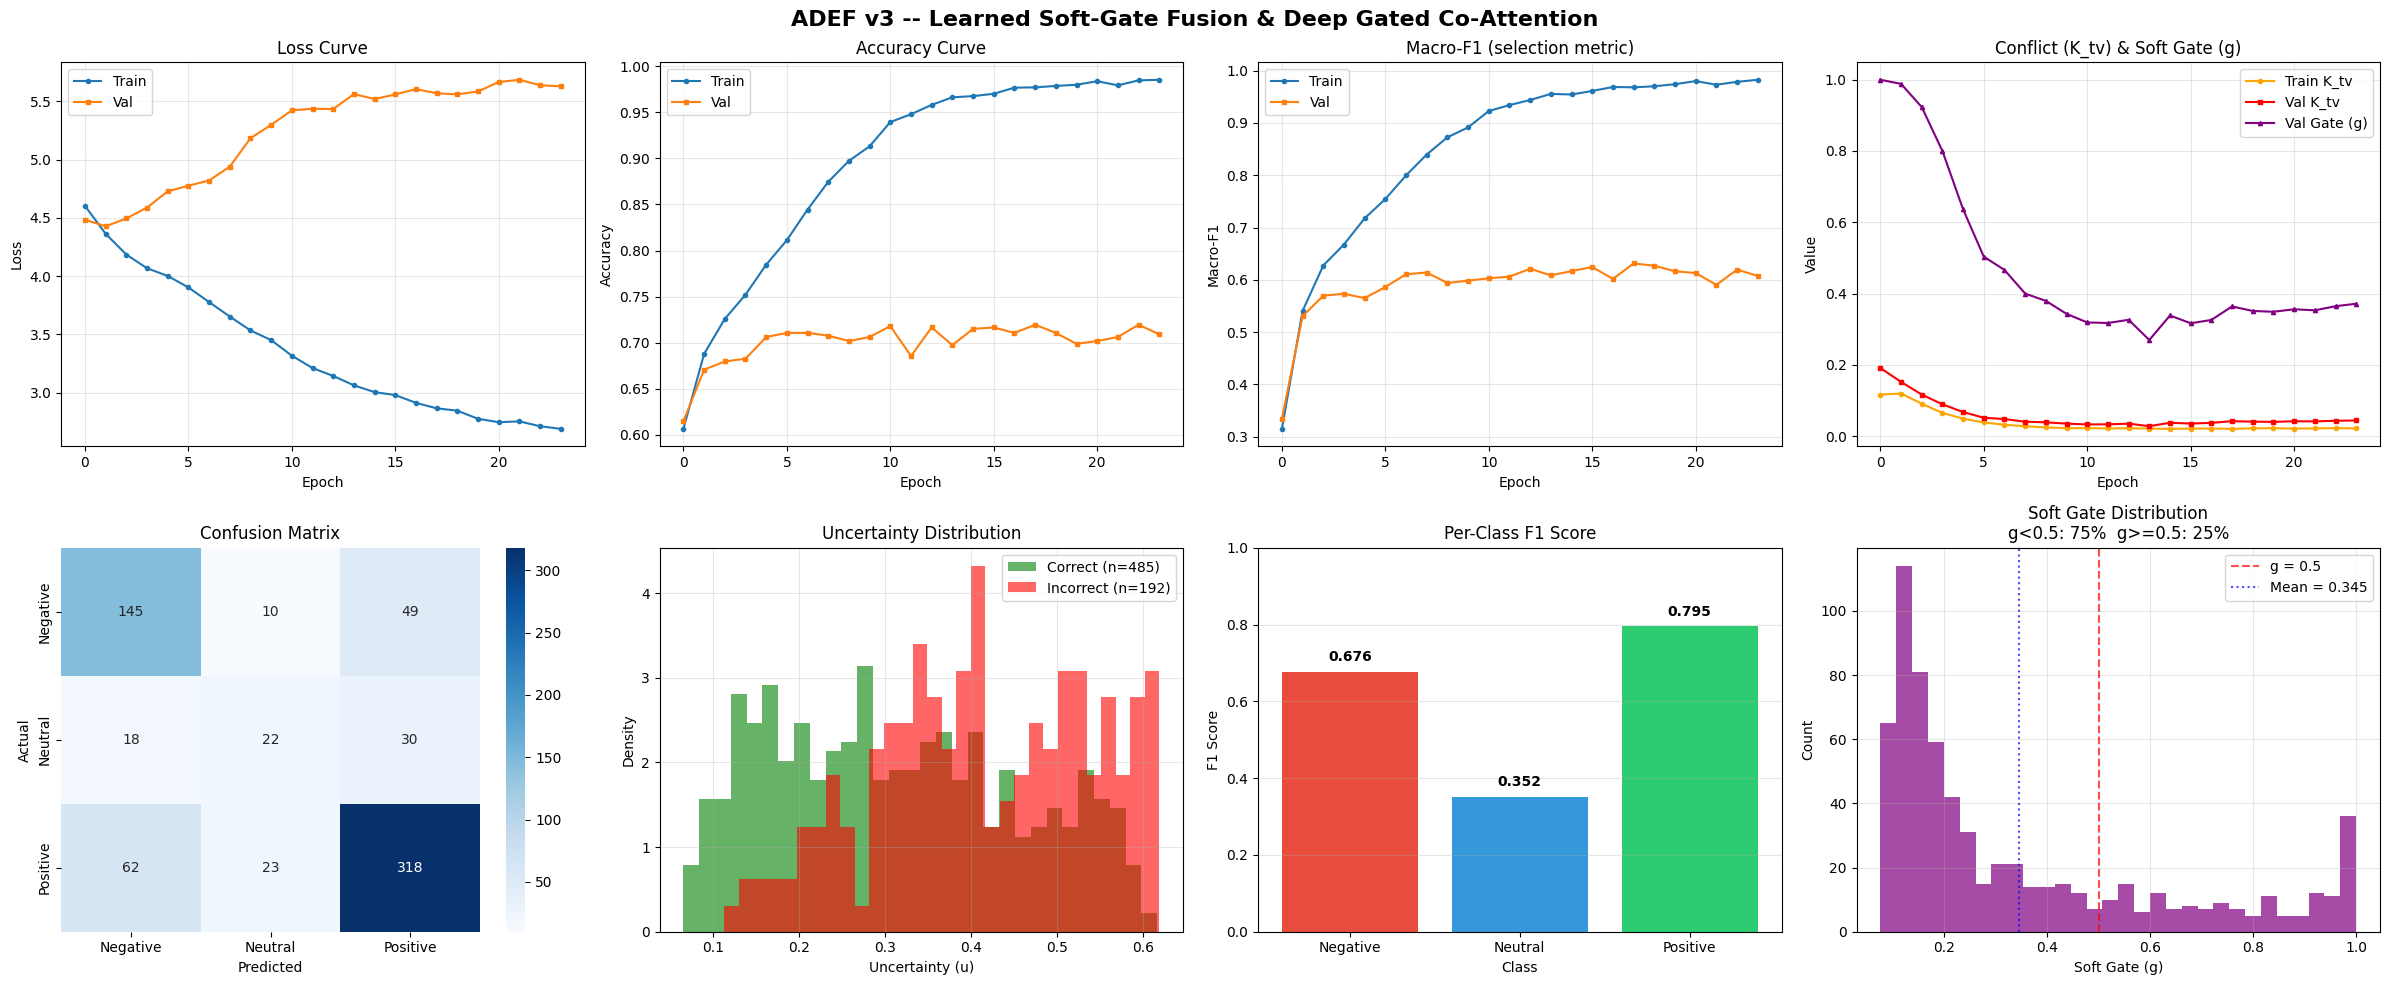

✅ Visualization complete. Saved as adef_v3_results.png


In [14]:
# ============================================================
# EXPERIMENT E1: ADEF v3 Full (3 seeds, FILTER_CONFLICT_PAIRS=True)
# ============================================================

print("=" * 60)
print("  EXPERIMENT E1: ADEF v3 Full (3 seeds)")
print(f"  FILTER_CONFLICT_PAIRS = {CFG.FILTER_CONFLICT_PAIRS}")
print(f"  GATE_TYPE = {CFG.GATE_TYPE},  EDL_LOSS_TYPE = {CFG.EDL_LOSS_TYPE}")
print(f"  COATTN_LAYERS = {CFG.COATTN_LAYERS},  OPINION_DROP = {CFG.OPINION_DROP_PROB}")
print(f"  DISCOUNTING = {CFG.USE_DISCOUNTING},  GAMMA = {CFG.GAMMA}")
print("=" * 60)

all_seed_results = []
all_seed_histories = []
learned_params = []

for seed in CFG.SEEDS:
    print(f"\n{'#'*50}")
    print(f"  Seed {seed}")
    print(f"{'#'*50}")

    model_trained, best_state, best_score, history = train_one_seed(seed)

    # Evaluate with best checkpoint
    model_eval = create_model_v3()
    model_eval.load_state_dict(best_state)
    res = evaluate_test(model_eval, test_loader)

    all_seed_results.append(res)
    all_seed_histories.append(history)

    # Collect learned gate parameters
    if CFG.GATE_TYPE == "parametric":
        tau_learned = 0.01 + 0.49 * torch.sigmoid(model_eval.adef.gate.theta_tau).item()
        s_learned = F.softplus(model_eval.adef.gate.theta_temp).item() + 1e-4
        r_vals = []
        if CFG.USE_DISCOUNTING:
            r_vals = [
                torch.sigmoid(model_eval.adef.discounter_t.raw_r).item(),
                torch.sigmoid(model_eval.adef.discounter_v.raw_r).item(),
                torch.sigmoid(model_eval.adef.discounter_c.raw_r).item()
            ]
        learned_params.append({"tau": tau_learned, "s": s_learned, "r": r_vals, "seed": seed})

    print(f"  Seed {seed}: Best val F1m={best_score:.4f} | Test F1m={res['f1_macro']:.4f} | Epochs={history['best_epoch']}")

    del model_trained, model_eval
    torch.cuda.empty_cache()

# ---- Aggregate over seeds ----
print(f"\n{'='*60}")
print("  AGGREGATED 3-SEED RESULTS (mean +/- std)")
print(f"{'='*60}")
agg_keys = ["acc", "f1_weighted", "f1_macro", "f1_neg", "f1_neu", "f1_pos", "uce",
            "gate_mean", "k_tv_mean", "u_correct", "u_incorrect"]
for key in agg_keys:
    vals = [r[key] for r in all_seed_results]
    mu, std = np.mean(vals), np.std(vals)
    print(f"  {key:<25s}: {mu:.4f} +/- {std:.4f}")

# ---- Learned parameters ----
if learned_params:
    print(f"\n  Learned Gate Parameters:")
    for lp in learned_params:
        print(f"    Seed {lp['seed']}: tau={lp['tau']:.4f}  s={lp['s']:.4f}", end="")
        if lp['r']:
            print(f"  r[t,v,c]=[{lp['r'][0]:.3f}, {lp['r'][1]:.3f}, {lp['r'][2]:.3f}]")
        else:
            print()

print(f"\n  Best epochs: {[h['best_epoch'] for h in all_seed_histories]}")

# Store last seed result for visualization
best_res = all_seed_results[-1]
best_hist = all_seed_histories[-1]
print("\n\u2705 E1 complete.")


# ============================================================
# VISUALIZATION (v3: gate distribution replaces tau-based routing)
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(24, 10))
fig.suptitle("ADEF v3 -- Learned Soft-Gate Fusion & Deep Gated Co-Attention", fontsize=16, fontweight="bold")

# 1. Loss Curve
axes[0, 0].plot(best_hist["train_loss"], label="Train", marker="o", markersize=3)
axes[0, 0].plot(best_hist["val_loss"], label="Val", marker="s", markersize=3)
axes[0, 0].set_xlabel("Epoch"); axes[0, 0].set_ylabel("Loss")
axes[0, 0].set_title("Loss Curve"); axes[0, 0].legend(); axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy Curve
axes[0, 1].plot(best_hist["train_acc"], label="Train", marker="o", markersize=3)
axes[0, 1].plot(best_hist["val_acc"], label="Val", marker="s", markersize=3)
axes[0, 1].set_xlabel("Epoch"); axes[0, 1].set_ylabel("Accuracy")
axes[0, 1].set_title("Accuracy Curve"); axes[0, 1].legend(); axes[0, 1].grid(True, alpha=0.3)

# 3. Macro-F1 Curve
axes[0, 2].plot(best_hist["train_f1_macro"], label="Train", marker="o", markersize=3)
axes[0, 2].plot(best_hist["val_f1_macro"], label="Val", marker="s", markersize=3)
axes[0, 2].set_xlabel("Epoch"); axes[0, 2].set_ylabel("Macro-F1")
axes[0, 2].set_title("Macro-F1 (selection metric)"); axes[0, 2].legend(); axes[0, 2].grid(True, alpha=0.3)

# 4. Conflict K_tv + Soft Gate
ax_cg = axes[0, 3]
ax_cg.plot(best_hist["train_conflict"], label="Train K_tv", marker="o", markersize=3, color="orange")
ax_cg.plot(best_hist["val_conflict"], label="Val K_tv", marker="s", markersize=3, color="red")
ax_cg.plot(best_hist["val_gate"], label="Val Gate (g)", marker="^", markersize=3, color="purple")
ax_cg.set_xlabel("Epoch"); ax_cg.set_ylabel("Value")
ax_cg.set_title("Conflict (K_tv) & Soft Gate (g)"); ax_cg.legend(); ax_cg.grid(True, alpha=0.3)

# 5. Confusion Matrix
cm = confusion_matrix(best_res["labels"], best_res["preds"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Neutral", "Positive"],
            yticklabels=["Negative", "Neutral", "Positive"],
            ax=axes[1, 0])
axes[1, 0].set_xlabel("Predicted"); axes[1, 0].set_ylabel("Actual")
axes[1, 0].set_title("Confusion Matrix")

# 6. Uncertainty Distribution (Correct vs Incorrect)
correct_mask = best_res["preds"] == best_res["labels"]
axes[1, 1].hist(best_res["uncertainties"][correct_mask], bins=30, alpha=0.6,
                label=f"Correct (n={correct_mask.sum()})", color="green", density=True)
if (~correct_mask).sum() > 0:
    axes[1, 1].hist(best_res["uncertainties"][~correct_mask], bins=30, alpha=0.6,
                    label=f"Incorrect (n={(~correct_mask).sum()})", color="red", density=True)
axes[1, 1].set_xlabel("Uncertainty (u)"); axes[1, 1].set_ylabel("Density")
axes[1, 1].set_title("Uncertainty Distribution"); axes[1, 1].legend(); axes[1, 1].grid(True, alpha=0.3)

# 7. Per-Class F1 Scores
class_names = ["Negative", "Neutral", "Positive"]
f1_per = [best_res["f1_neg"], best_res["f1_neu"], best_res["f1_pos"]]
bars = axes[1, 2].bar(class_names, f1_per, color=["#e74c3c", "#3498db", "#2ecc71"])
axes[1, 2].set_xlabel("Class"); axes[1, 2].set_ylabel("F1 Score")
axes[1, 2].set_title("Per-Class F1 Score"); axes[1, 2].set_ylim(0, 1)
for bar, val in zip(bars, f1_per):
    axes[1, 2].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
                    f"{val:.3f}", ha="center", va="bottom", fontweight="bold")
axes[1, 2].grid(True, alpha=0.3, axis="y")

# 8. Soft Gate Distribution
axes[1, 3].hist(best_res["gates"], bins=30, alpha=0.7, color="purple")
axes[1, 3].axvline(x=0.5, color="red", linestyle="--", alpha=0.7, label="g = 0.5")
axes[1, 3].axvline(x=best_res["gate_mean"], color="blue", linestyle=":", alpha=0.7,
                   label=f"Mean = {best_res['gate_mean']:.3f}")
axes[1, 3].set_xlabel("Soft Gate (g)"); axes[1, 3].set_ylabel("Count")
axes[1, 3].set_title(f"Soft Gate Distribution\ng<0.5: {best_res['ds_like_pct']:.0f}%  g>=0.5: {best_res['conflict_pct']:.0f}%")
axes[1, 3].legend(); axes[1, 3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("adef_v3_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\u2705 Visualization complete. Saved as adef_v3_results.png")


In [15]:
# ============================================================
# ABLATION EXPERIMENTS (E2-E8)
# ============================================================
# Quick ablations -- 1 seed each, compares Macro-F1.
# Saved for manual exploration; not required for thesis proof.

def run_ablation(name, overrides, seed=42):
    set_seed(seed)
    torch.cuda.empty_cache()
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"  Overrides: {overrides}")
    print(f"{'='*50}")

    _, best_state, best_score, hist = train_one_seed(seed, overrides)

    model_eval = create_model_v3(overrides)
    model_eval.load_state_dict(best_state)
    res = evaluate_test(model_eval, test_loader)
    print_results(res, title=name)

    del model_eval
    torch.cuda.empty_cache()
    return res

experiments = []

# E2: Hard routing (disable discounting + dropout, parametric gate still soft)
# True hard routing needs gate_type="hard" which doesn"t exist --
# this is V2-style: single-layer co-attention, no discounting, no dropout
res = run_ablation("E2: v2-style (1-layer, no disc, no drop)", {
    "coattn_layers": 1, "use_discounting": False, "opinion_drop_prob": 0.0,
    "gate_type": "parametric"
})
experiments.append(["E2: v2-style", res["f1_macro"], res["f1_neu"], res["acc"]])

# E3: No vacuous dropout
res = run_ablation("E3: No vacuous dropout", {"opinion_drop_prob": 0.0})
experiments.append(["E3: No vac drop", res["f1_macro"], res["f1_neu"], res["acc"]])

# E4: 1-layer co-attention
res = run_ablation("E4: 1-layer co-attention", {"coattn_layers": 1})
experiments.append(["E4: 1-layer CA", res["f1_macro"], res["f1_neu"], res["acc"]])

# E5: MLP gate
res = run_ablation("E5: MLP gate", {"gate_type": "mlp"})
experiments.append(["E5: MLP gate", res["f1_macro"], res["f1_neu"], res["acc"]])

# E6: SOS loss
old_loss = CFG.EDL_LOSS_TYPE
CFG.EDL_LOSS_TYPE = "sos"
res = run_ablation("E6: SOS loss", {})
CFG.EDL_LOSS_TYPE = old_loss
experiments.append(["E6: SOS loss", res["f1_macro"], res["f1_neu"], res["acc"]])

# E7: No discounting
res = run_ablation("E7: No discounting", {"use_discounting": False})
experiments.append(["E7: No discount", res["f1_macro"], res["f1_neu"], res["acc"]])

# E8: Both loss types
CFG.EDL_LOSS_TYPE = "both"
res = run_ablation("E8: Both (digamma+sos)", {})
CFG.EDL_LOSS_TYPE = "digamma"
experiments.append(["E8: Both losses", res["f1_macro"], res["f1_neu"], res["acc"]])

# Summary table
print(f"\n{'='*60}")
print("  ABLATION SUMMARY (1-seed each)")
print(f"{'='*60}")
print(f"  {'Ablation':<25s} | {'Macro F1':>8s} | {'Neu F1':>6s} | {'Acc':>6s}")
print("-" * 58)
for row in experiments:
    print(f"  {row[0]:<25s} | {row[1]:>8.4f} | {row[2]:>6.4f} | {row[3]:>6.4f}")
print(f"{'='*60}")
print("\n\u2705 Ablation experiments complete.")



  E2: v2-style (1-layer, no disc, no drop)
  Overrides: {'coattn_layers': 1, 'use_discounting': False, 'opinion_drop_prob': 0.0, 'gate_type': 'parametric'}


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5957.95it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Class weights (Neg/Neu/Pos): [1.0520000457763672, 1.7879999876022339, 0.7490000128746033]


Seed 42 E 1/30 | TL: 4.6086 VL: 4.4663 | TA: 0.5908 VA: 0.6100 | VF1m: 0.3560 | K_tv: 0.2551 Gate: 1.000
  * New best! Val F1m: 0.3560


Seed 42 E 2/30 | TL: 4.3825 VL: 4.4201 | TA: 0.6804 VA: 0.6632 | VF1m: 0.5308 | K_tv: 0.1848 Gate: 0.996
  * New best! Val F1m: 0.5308


...

Seed 42 E 9/30 | TL: 2.7259 VL: 4.0847 | TA: 0.8958 VA: 0.6721 | VF1m: 0.5642 | K_tv: 0.0295 Gate: 0.305


Seed 42 E10/30 | TL: 2.6794 VL: 4.2285 | TA: 0.9050 VA: 0.6883 | VF1m: 0.5794 | K_tv: 0.0311 Gate: 0.315


Seed 42 E11/30 | TL: 2.5411 VL: 4.2292 | TA: 0.9300 VA: 0.7016 | VF1m: 0.6006 | K_tv: 0.0275 Gate: 0.282
  Early stop at epoch 11 (no improvement for 6 epochs)


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 6727.11it/s]
[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
                                                                


  E8: Both (digamma+sos)
  Accuracy:          0.7016
  F1 (Weighted):     0.6955
  F1 (Macro):        0.5901
  F1 (Negative):     0.6297
  F1 (Neutral):      0.3520
  F1 (Positive):     0.7885
  UCE:               0.1543
  Soft Gate Statistics:
    Mean / Median:   0.4701 / 0.4086
    g < 0.5 (DS-like):  63.5%
    g >= 0.5 (conflict): 36.5%
  Conflict K_tv:
    Mean:            0.0472 +/- 0.0291
    p50/p80/p90/p95: [0.0395, 0.0629, 0.0847, 0.1082]
  Uncertainty:
    u(correct):      0.4238
    u(incorrect):    0.5206

Classification Report:
              precision    recall  f1-score   support

    Negative       0.65      0.61      0.63       204
     Neutral       0.40      0.31      0.35        70
    Positive       0.76      0.81      0.79       403

    accuracy                           0.70       677
   macro avg       0.60      0.58      0.59       677
weighted avg       0.69      0.70      0.70       677


  ABLATION SUMMARY (1-seed each)
  Ablation                  | Macro 